In [33]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import json
import random
import os
import re
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data set over whole period; dates and duplicates not addressed

In [2]:
# read parquet file here
dataDir = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/results_status_dates/processed/dataframes'
mergedNotesMaster = pd.read_parquet(f'{dataDir}/merged_processed_clinicalNotes.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)

## Plot note count per procedure per month

In [3]:
datesOnly = mergedNotesMaster[['visitDate', 'Observations.ProcName']].copy()
datesOnly['visitDate'] = pd.to_datetime( datesOnly['visitDate'], utc=True )
datesOnly['year'] = datesOnly['visitDate'].dt.year
datesOnly['month'] = datesOnly['visitDate'].dt.month
datesOnly['visit_month'] = pd.to_datetime( dict(year = datesOnly.year, month=datesOnly.month, day = 28) )
datesOnly = datesOnly.loc[ datesOnly['year'] >= 2004 ]
notesCountProcedure = datesOnly.groupby(['Observations.ProcName', 'visit_month']).size().reset_index(name='notesCount')
notesCountProcedure.sort_values(by=['visit_month'], inplace=True)
uniqueProcName = list( notesCountProcedure['Observations.ProcName'].unique() )
notesCountProcedure['Observations.ProcName'] = pd.Categorical( notesCountProcedure['Observations.ProcName'], ordered=True, categories=uniqueProcName )
notesCountProcedure['visit_month'] = notesCountProcedure['visit_month'].dt.date
notesCountProcedure

,Observations.ProcName,visit_month,notesCount
0,Clinic Note,2004-02-28,1
1,Clinic Note,2004-05-28,1
260,Communication Note,2004-05-28,1
826,Letter,2004-11-28,1
2,Clinic Note,2005-02-28,1
...,...,...,...
825,History & Physical Note,2021-01-28,55
189,Clinic Note,2021-02-28,2
538,Consultation Note,2021-02-28,1
650,Discharge Summary,2021-02-28,10


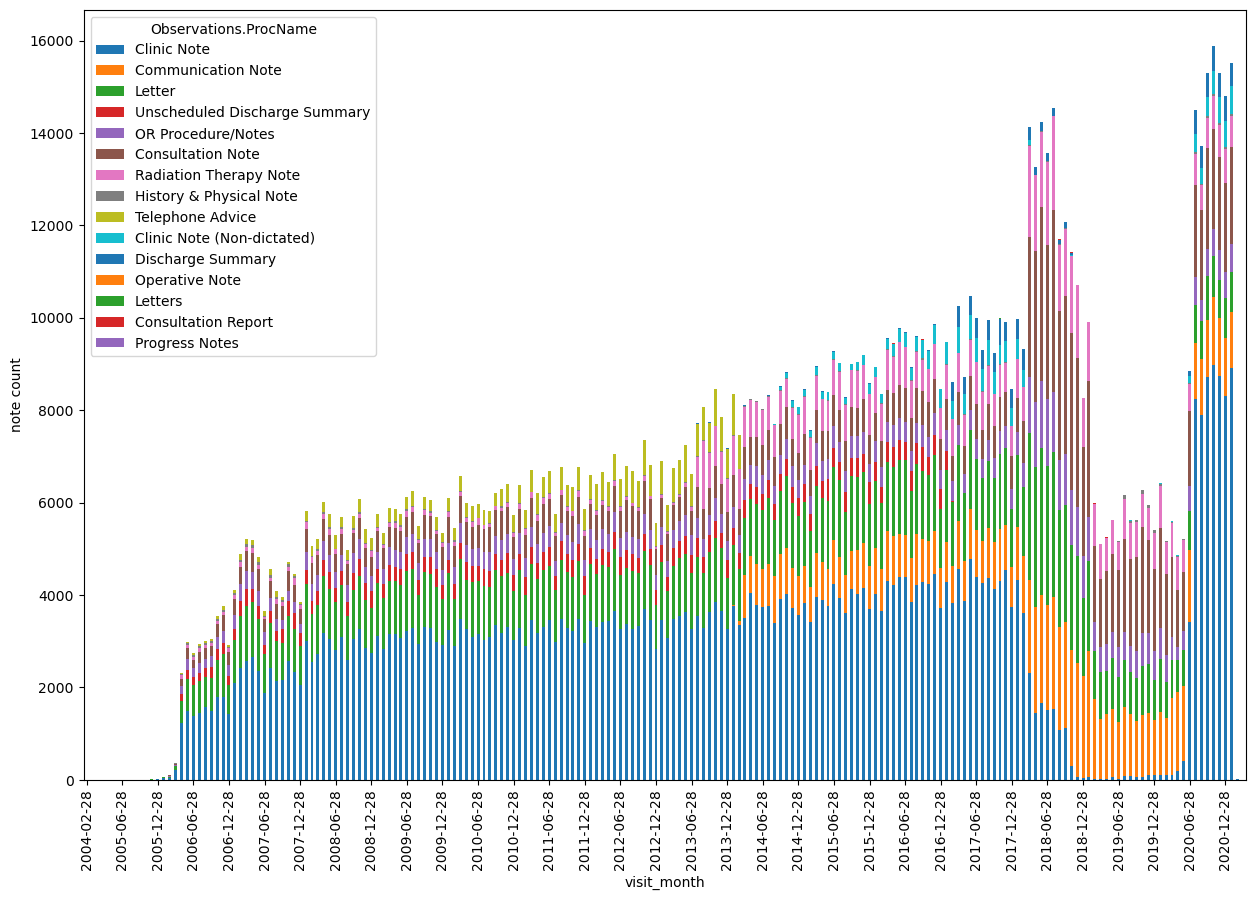

In [4]:
ax = notesCountProcedure.pivot(index = 'visit_month', columns='Observations.ProcName', values='notesCount').plot(kind = 'bar', stacked = True, figsize=(15,10))
ax.set_xticks(ax.get_xticks()[::6]);
ax.set_ylabel("note count");

## Plot note count per medical oncologist per month

In [5]:
# load list of medical oncologists of interest
import sys
sys.path.insert(1, "/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/constants")
from constants import aliasDictionary
medOncList = list( set( aliasDictionary.values() ) )

In [6]:
# keep visitDate and physician name
dfMedOncCount = mergedNotesMaster.loc[ mergedNotesMaster['processed_physician_name'].isin(medOncList), ['visitDate', 'processed_physician_name']].copy()
dfMedOncCount['visitDate'] = pd.to_datetime( dfMedOncCount['visitDate'], utc=True )
dfMedOncCount['year'] = datesOnly['visitDate'].dt.year
dfMedOncCount['month'] = datesOnly['visitDate'].dt.month
dfMedOncCount['visit_month'] = pd.to_datetime( dict(year = dfMedOncCount.year, month=dfMedOncCount.month, day = 28) )
dfMedOncCount = dfMedOncCount.loc[ dfMedOncCount['year'] >= 2004 ]
notesCountMedOnc = dfMedOncCount.groupby(['processed_physician_name', 'visit_month']).size().reset_index(name='notesCount')
notesCountMedOnc.sort_values(by=['visit_month'], inplace=True)
notesCountMedOnc.rename(columns={"processed_physician_name": "medical_onc"}, inplace=True)
medOncTotalNotes = notesCountMedOnc.groupby(['medical_onc'])['notesCount'].sum().reset_index(name='totalNotes').sort_values(by = 'totalNotes', ascending=False)
medOncList = list( medOncTotalNotes['medical_onc'].unique() )
notesCountMedOnc['medical_onc'] = pd.Categorical( notesCountMedOnc['medical_onc'], ordered=True, categories=medOncList )
notesCountMedOnc['visit_month'] = notesCountMedOnc['visit_month'].dt.date
notesCountMedOnc

,medical_onc,visit_month,notesCount
672,Frances Alice Shepherd,2005-02-28,1
2418,Xueyu Eric Chen,2005-11-28,1
1054,Jennifer Jane Knox,2005-11-28,1
1237,Lillian L. Y. Siu,2005-12-28,1
1055,Jennifer Jane Knox,2005-12-28,2
...,...,...,...
2396,Robert Charles Grant,2021-01-28,59
2382,Rebecca Michelle Prince,2021-01-28,210
853,Frances Alice Shepherd,2021-01-28,205
1728,Monika Karolina Krzyzanowska,2021-01-28,22


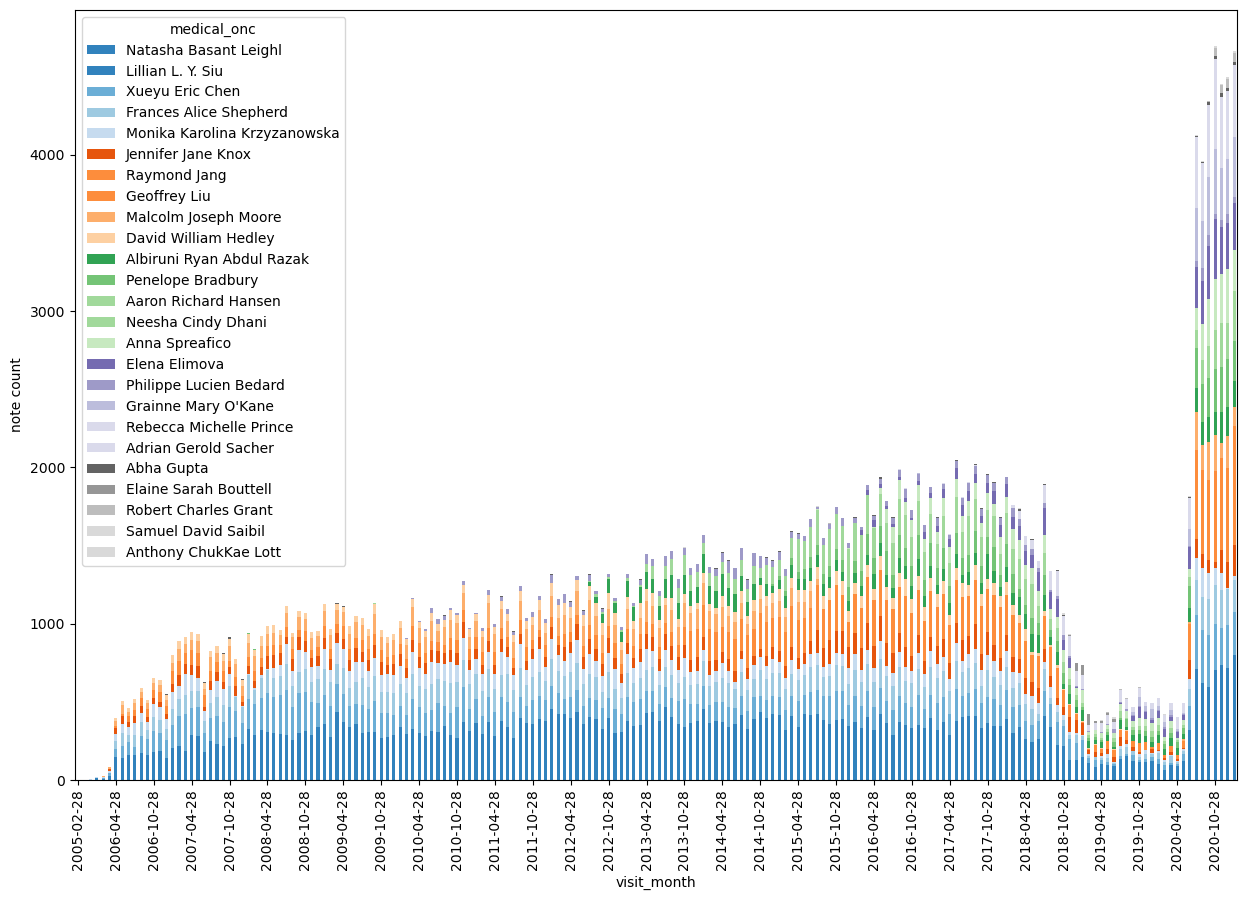

In [7]:
fig, ax = plt.subplots(figsize=(15, 10));
dfpivot = notesCountMedOnc.pivot(index = 'visit_month', columns='medical_onc', values='notesCount')
dfpivot.plot(kind = 'bar', colormap='tab20c', stacked = True, figsize=(15,10), ax=ax)
ax.set_xticks(ax.get_xticks()[::6]);
ax.set_ylabel('note count');

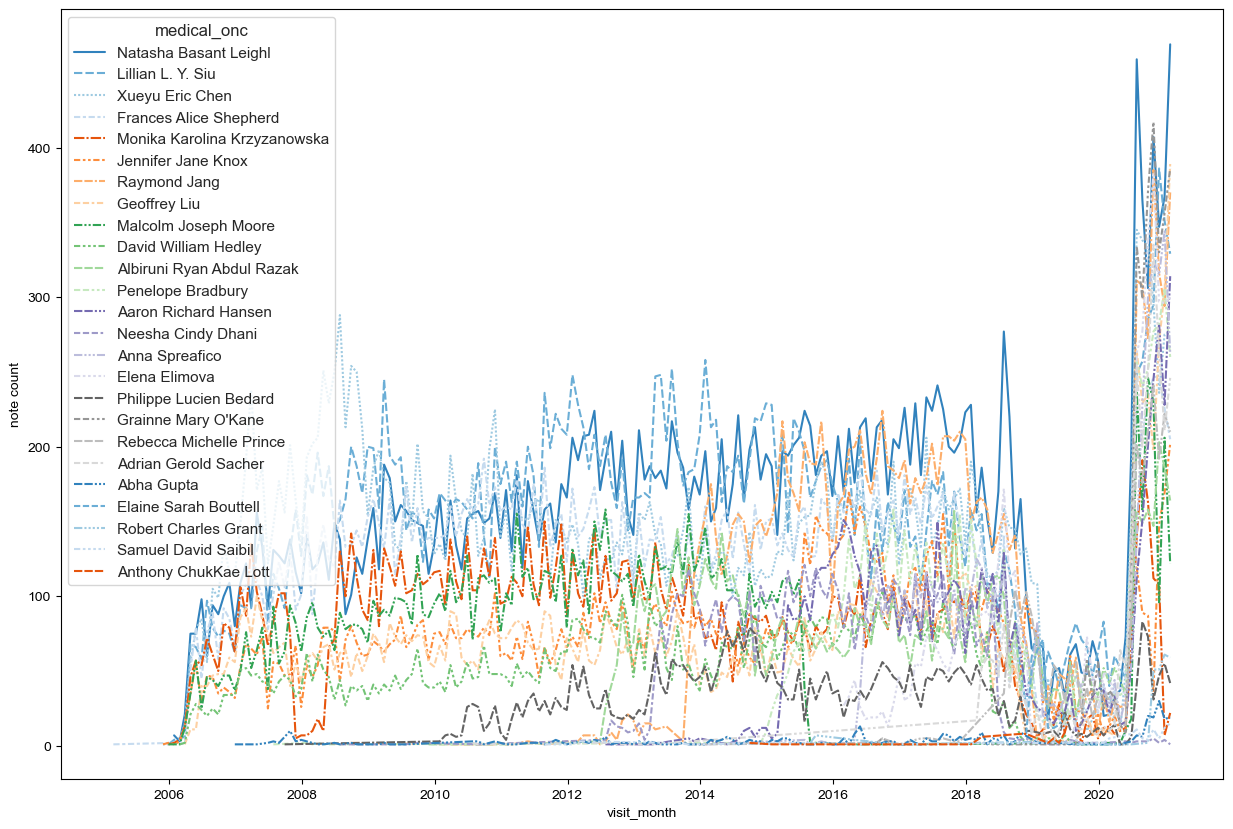

In [8]:
fig, ax = plt.subplots(figsize=(15, 10));
sns.set_theme()
sns.set_style("whitegrid")
sns.set_palette("tab20c", n_colors=25)
sns.lineplot(data=notesCountMedOnc, x="visit_month", y='notesCount', hue='medical_onc', style='medical_onc', ax=ax);
ax.set_ylabel('note count');

## Plot number of new patients per month

In [14]:
mergedNotesMaster['visitDate'] = pd.to_datetime( mergedNotesMaster['visitDate'], utc=True )
mergedNotesMaster.sort_values( by='visitDate', inplace=True )
df_first_visit = mergedNotesMaster.groupby(['PATIENT_RESEARCH_ID']).first().reset_index()
df_first_visit['year'] = df_first_visit['visitDate'].dt.year
df_first_visit['month'] = df_first_visit['visitDate'].dt.month
df_first_visit['visit_month'] = pd.to_datetime( dict(year = df_first_visit.year, month=df_first_visit.month, day = 28) )
df_first_visit = df_first_visit.loc[ df_first_visit['year'] >= 2004 ]
patientCount = df_first_visit.groupby(['visit_month']).size().reset_index(name='patientCount')
patientCount['visit_month'] = patientCount['visit_month'].dt.date
patientCount

,visit_month,patientCount
0,2004-02-28,1
1,2004-05-28,1
2,2004-11-28,1
3,2005-02-28,1
4,2005-04-28,4
...,...,...
189,2020-09-28,245
190,2020-10-28,240
191,2020-11-28,269
192,2020-12-28,216


Text(0, 0.5, 'patient count')

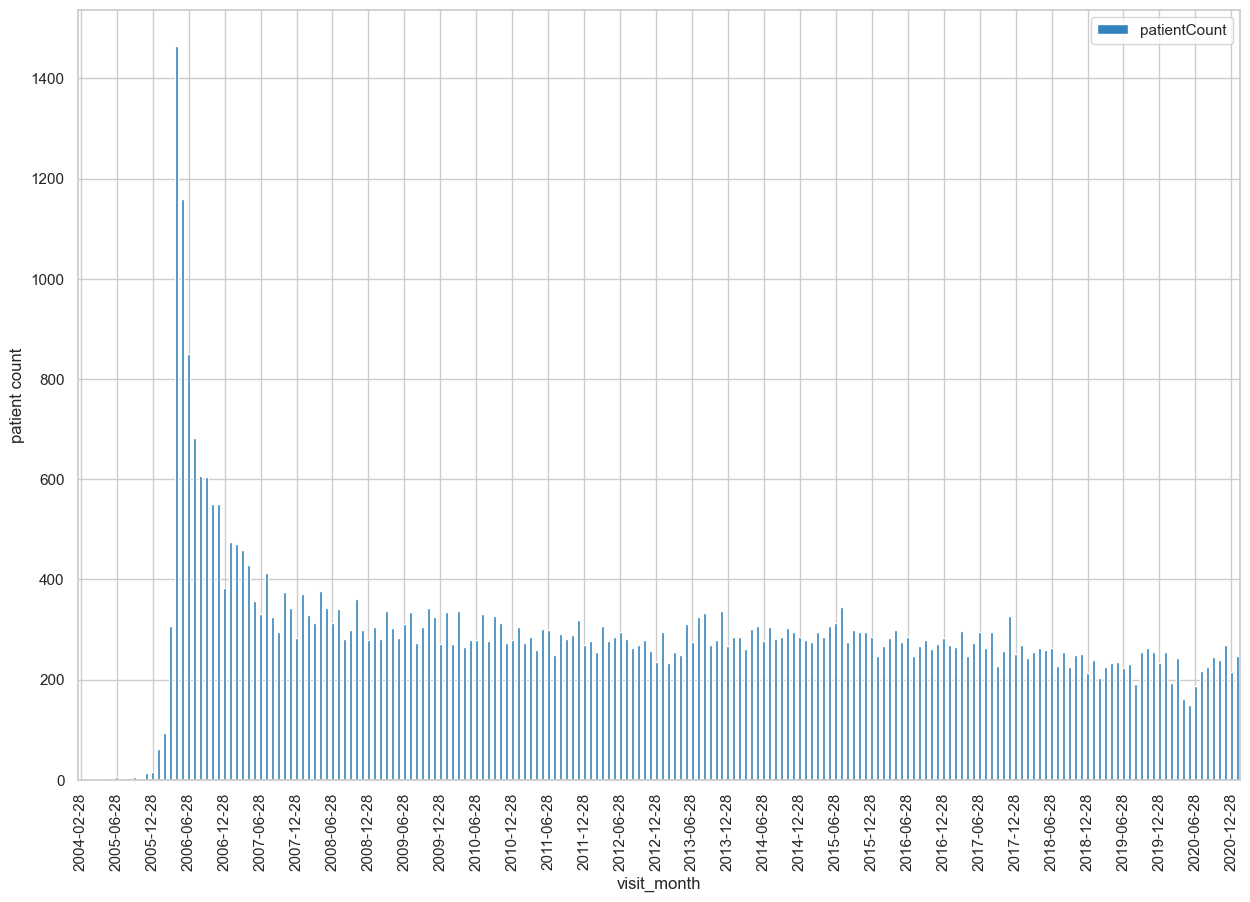

In [10]:
ax = patientCount.plot(kind = 'bar', x = 'visit_month', y='patientCount', figsize=(15,10))
ax.set_xticks(ax.get_xticks()[::6]);
ax.set_ylabel('patient count')

In [15]:
# Plot proportion of new patients thus far
patientCount['ecdf'] = patientCount['patientCount'].cumsum()/patientCount['patientCount'].sum()
patientCount

,visit_month,patientCount,ecdf
0,2004-02-28,1,0.000018
1,2004-05-28,1,0.000036
2,2004-11-28,1,0.000054
3,2005-02-28,1,0.000072
4,2005-04-28,4,0.000145
...,...,...,...
189,2020-09-28,245,0.982439
190,2020-10-28,240,0.986780
191,2020-11-28,269,0.991645
192,2020-12-28,216,0.995551


Text(0.5, 0, 'visit month')

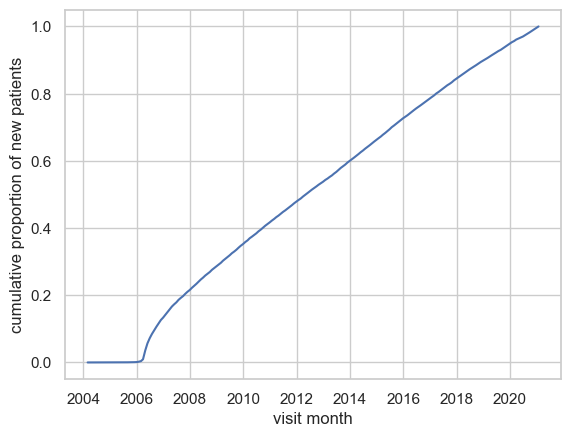

In [17]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=patientCount, x="visit_month", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of new patients')
ax.set_xlabel('visit month')

# Data set cleaned for dates and duplicates restricted to 2008-01-01 and 2017-12-31 (patient first visit must be within study period)

In [34]:
# read parquet file here
startDate='2008-01-01'
endDate='2017-12-31'
dataDir = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/results_status_dates/processed/dataframes'
filteredNotes = pd.read_parquet(f'{dataDir}/merged_processed_cleaned_clinicalNotes_{startDate}_{endDate}.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)

## Plot note count per procedure per month

In [35]:
datesOnly = filteredNotes[['processed_date', 'Observations.ProcName']].copy()
datesOnly['processed_date'] = pd.to_datetime( datesOnly['processed_date'], utc=True )
datesOnly['year'] = datesOnly['processed_date'].dt.year
datesOnly['month'] = datesOnly['processed_date'].dt.month
datesOnly['visit_month'] = pd.to_datetime( dict(year = datesOnly.year, month=datesOnly.month, day = 28) )
notesCountProcedure = datesOnly.groupby(['Observations.ProcName', 'visit_month']).size().reset_index(name='notesCount')
notesCountProcedure.sort_values(by=['visit_month'], inplace=True)
uniqueProcName = list( notesCountProcedure['Observations.ProcName'].unique() )
notesCountProcedure['Observations.ProcName'] = pd.Categorical( notesCountProcedure['Observations.ProcName'], ordered=True, categories=uniqueProcName )
notesCountProcedure['visit_month'] = notesCountProcedure['visit_month'].dt.date
notesCountProcedure

,Observations.ProcName,visit_month,notesCount
0,Clinic Note,2008-01-28,115
410,History & Physical Note,2008-01-28,18
530,Letter,2008-01-28,306
657,OR Procedure/Notes,2008-01-28,68
913,Telephone Advice,2008-01-28,25
...,...,...,...
912,Radiation Therapy Note,2017-12-28,624
649,Letter,2017-12-28,1011
529,History & Physical Note,2017-12-28,5
409,Discharge Summary,2017-12-28,351


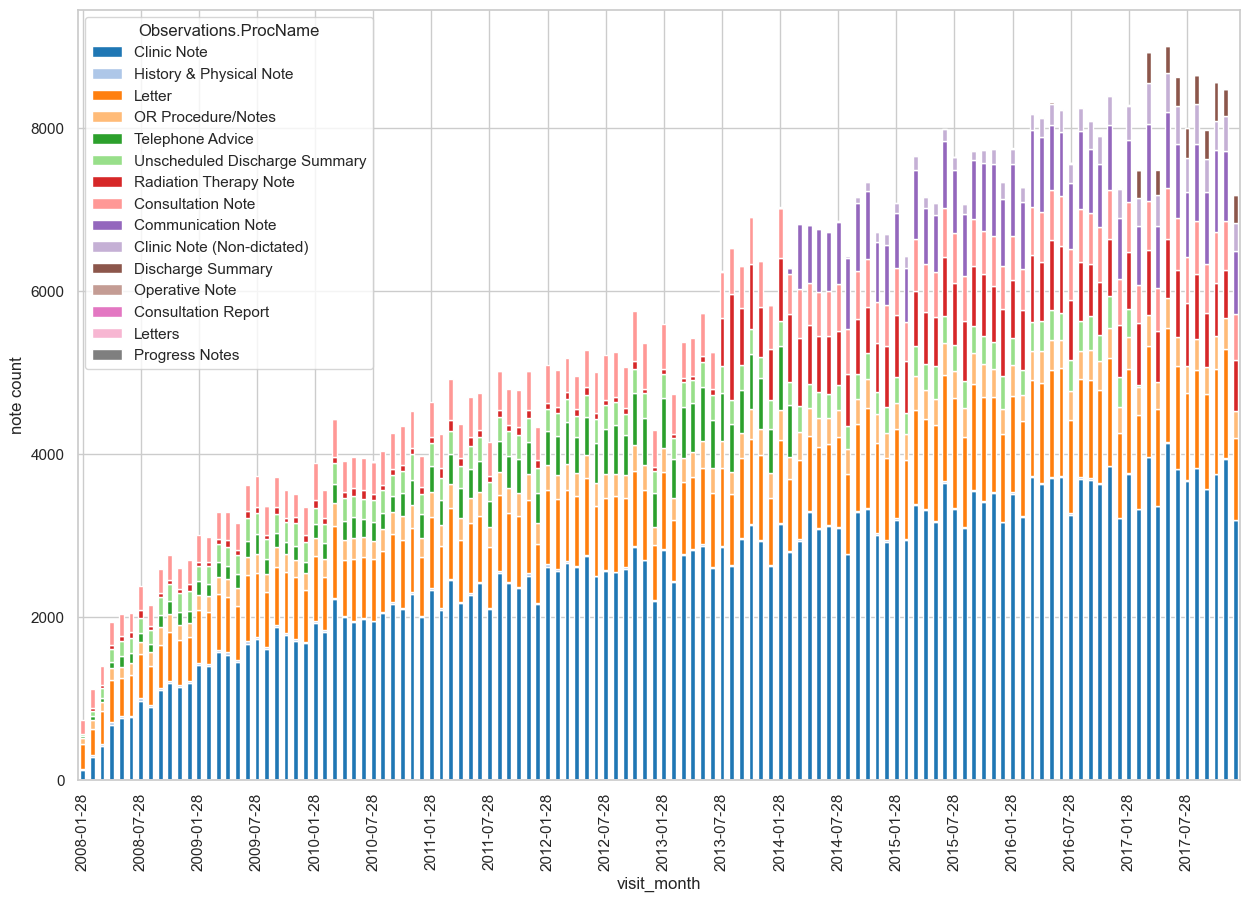

In [37]:
ax = notesCountProcedure.pivot(index = 'visit_month', columns='Observations.ProcName', values='notesCount').plot(kind = 'bar', stacked = True, figsize=(15,10))
ax.set_xticks(ax.get_xticks()[::6]);
ax.set_ylabel("note count");

In [ ]:
# investigate format of radiation therapy note
filteredNotes.sort_values(by='processed_date', inplace=True)
filteredNotes.loc[ filteredNotes['Observations.ProcName'] == 'Radiation Therapy Note' ].to_csv( '/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/Misc/radiation_therapy_note_format.csv' )

## Plot number of new patients per month

In [10]:
filteredNotes['processed_date'] = pd.to_datetime( filteredNotes['processed_date'], utc=True )
filteredNotes.sort_values( by='processed_date', inplace=True )
df_first_visit = filteredNotes.groupby(['MRN']).first().reset_index()
df_first_visit['year'] = df_first_visit['processed_date'].dt.year
df_first_visit['month'] = df_first_visit['processed_date'].dt.month
df_first_visit['visit_month'] = pd.to_datetime( dict(year = df_first_visit.year, month=df_first_visit.month, day = 28) )
patientCount = df_first_visit.groupby(['visit_month']).size().reset_index(name='patientCount')
patientCount['visit_month'] = patientCount['visit_month'].dt.date
patientCount

,visit_month,patientCount
0,2008-01-28,384
1,2008-02-28,339
2,2008-03-28,306
3,2008-04-28,378
4,2008-05-28,337
...,...,...
115,2017-08-28,298
116,2017-09-28,232
117,2017-10-28,255
118,2017-11-28,325


Text(0, 0.5, 'patient count')

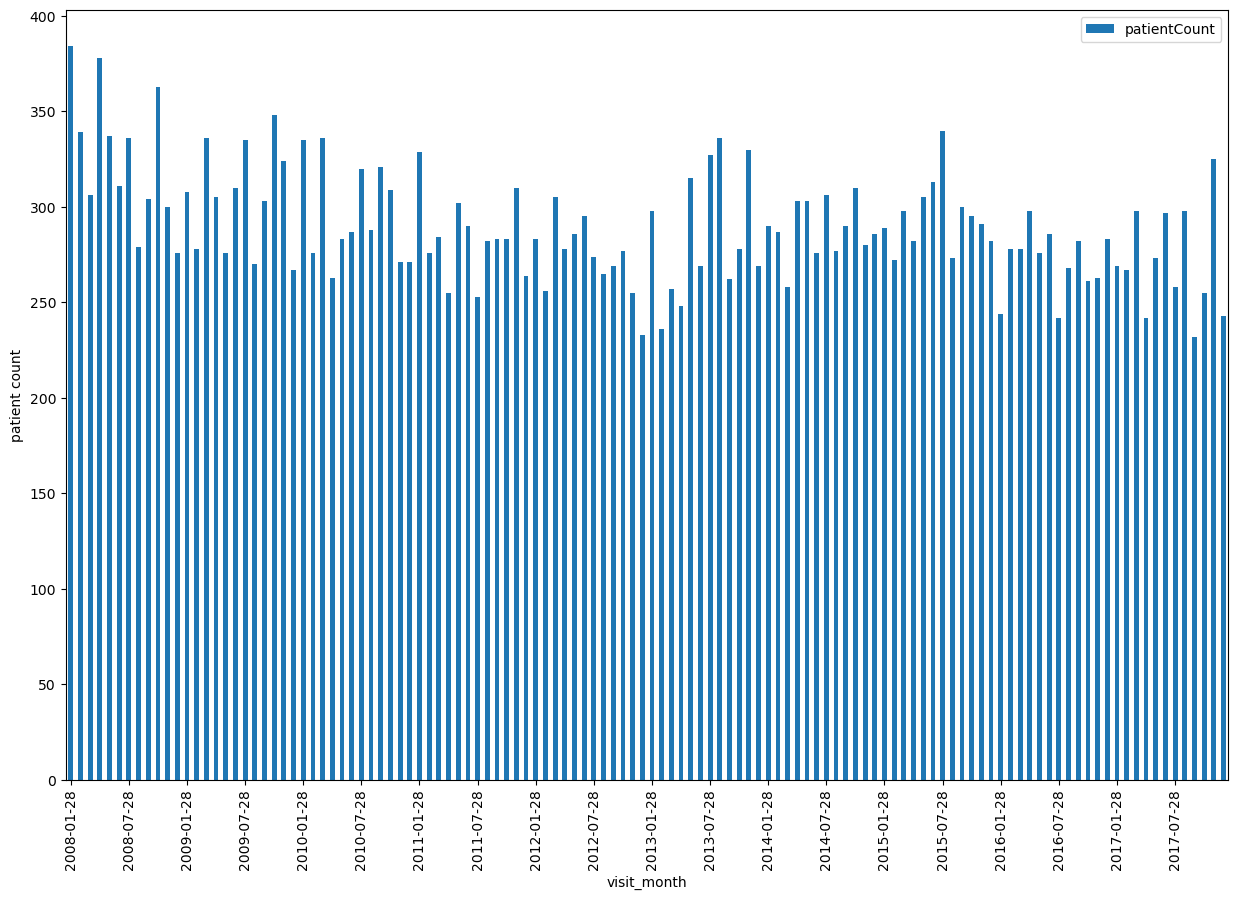

In [11]:
ax = patientCount.plot(kind = 'bar', x = 'visit_month', y='patientCount', figsize=(15,10))
ax.set_xticks(ax.get_xticks()[::6]);
ax.set_ylabel('patient count')

# Data set cleaned for dates and duplicates restricted to 2008-01-01 and 2017-12-31

In [12]:
# try different way of filtering
dataDir = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/results_status_dates/processed/dataframes'
cleanedNotes = pd.read_parquet(f'{dataDir}/merged_processed_cleaned_clinicalNotes.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)

## Plot note count per procedure per month

In [15]:
startDate='2008-01-01'
endDate='2017-12-31'
cleanedNotes = cleanedNotes.loc[ cleanedNotes['processed_date'].between(startDate, endDate) ]

In [16]:
datesOnly = cleanedNotes[['processed_date', 'Observations.ProcName']].copy()
datesOnly['processed_date'] = pd.to_datetime( datesOnly['processed_date'], utc=True )
datesOnly['year'] = datesOnly['processed_date'].dt.year
datesOnly['month'] = datesOnly['processed_date'].dt.month
datesOnly['visit_month'] = pd.to_datetime( dict(year = datesOnly.year, month=datesOnly.month, day = 28) )
notesCountProcedure = datesOnly.groupby(['Observations.ProcName', 'visit_month']).size().reset_index(name='notesCount')
notesCountProcedure.sort_values(by=['visit_month'], inplace=True)
uniqueProcName = list( notesCountProcedure['Observations.ProcName'].unique() )
notesCountProcedure['Observations.ProcName'] = pd.Categorical( notesCountProcedure['Observations.ProcName'], ordered=True, categories=uniqueProcName )
notesCountProcedure['visit_month'] = notesCountProcedure['visit_month'].dt.date
notesCountProcedure

,Observations.ProcName,visit_month,notesCount
0,Clinic Note,2008-01-28,3024
412,History & Physical Note,2008-01-28,39
532,Letter,2008-01-28,1249
659,OR Procedure/Notes,2008-01-28,401
918,Telephone Advice,2008-01-28,217
...,...,...,...
917,Radiation Therapy Note,2017-12-28,654
651,Letter,2017-12-28,1188
531,History & Physical Note,2017-12-28,6
411,Discharge Summary,2017-12-28,417


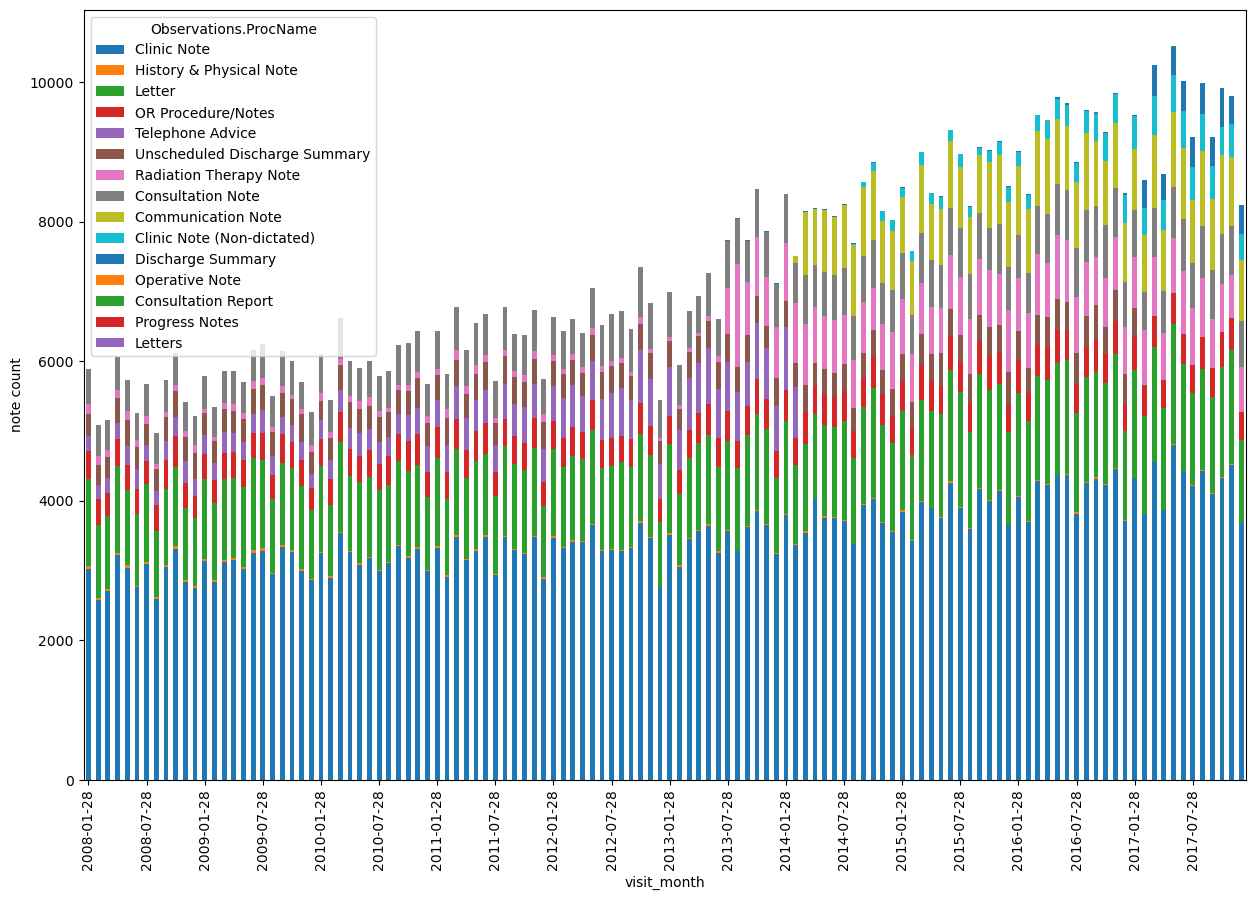

In [17]:
ax = notesCountProcedure.pivot(index = 'visit_month', columns='Observations.ProcName', values='notesCount').plot(kind = 'bar', stacked = True, figsize=(15,10))
ax.set_xticks(ax.get_xticks()[::6]);
ax.set_ylabel("note count");